In [1]:
import pprint
import csv
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import torch.optim as optim
import numpy as np
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from tqdm import tqdm
from torchinfo import summary
from PIL import Image

from variables import *
from model import EmotionClassifier
from get_dataset import GiMeFiveDataset

from os import mkdir, path, listdir

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# torch.set_default_device(device)
# torch.set_float32_matmul_precision("high")
# torch.backends.cudnn.benchmark = True

class_names = ["happiness", "surprise", "sadness", "anger", "disgust", "fear"]

print(f"Default device is :{torch.get_default_device()}")
print(f"Using device: {device}")
print(f"Running {experiment_name} experiment")
pprint.pp(configuration)

model_filename = f"{output_path}/{experiment_name}/model.pth"
if not path.exists(f"{output_path}/{experiment_name}"):
    mkdir(f"{output_path}/{experiment_name}")

Default device is :cpu
Using device: mps
Running leaky_relu experiment
{'apply_weighted_loss': False,
 'optimizer': 'sgd_optimizer',
 'dataset': 'GiMeFive',
 'use_scheduler': False,
 'use_label_smoothing': False,
 'hyperparameters': {'num_epochs': 80,
                     'batch_size': 16,
                     'learning_rate': 0.001,
                     'weight_decay': 0.0001,
                     'momentum': 0.9,
                     'dropout1': 0.2,
                     'conv5_filters': 1024,
                     'fc1_input': 1024,
                     'fc1_output': 2048,
                     'fc2_output': 1024}}


In [2]:
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = GiMeFiveDataset(
    csv_file=dataset["train"]["labels"],
    img_dir=dataset["train"]["images"],
    transform=transform,
)
train_data_loader = DataLoader(
    train_dataset,
    batch_size=hyperparameters["batch_size"],
    shuffle=True,
    num_workers=4,
)
train_image, train_label = next(iter(train_data_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

validation_dataset = GiMeFiveDataset(
    csv_file=dataset["validation"]["labels"],
    img_dir=dataset["validation"]["images"],
    transform=transform,
)
validation_data_loader = DataLoader(
    validation_dataset,
    batch_size=hyperparameters["batch_size"],
    shuffle=False,
    num_workers=0,
)
validation_image, validation_label = next(iter(validation_data_loader))
print(
    f"Validation batch: image shape {validation_image.shape}, labels shape {validation_label.shape}"
)

test_dataset = GiMeFiveDataset(
    csv_file=dataset["test"]["labels"],
    img_dir=dataset["test"]["images"],
    transform=transform,
)

test_data_loader = DataLoader(
    test_dataset,
    batch_size=hyperparameters["batch_size"],
    shuffle=False,
    num_workers=0,
)

test_image, test_label = next(iter(test_data_loader))
print(f"Test batch: image shape {test_image.shape}, labels shape {test_label.shape}")

Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Validation batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Test batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


In [3]:
model = EmotionClassifier().to(device)

print(
    summary(model, input_size=(hyperparameters["batch_size"], 3, 64, 64), device=device)
)

Layer (type:depth-idx)                   Output Shape              Param #
EmotionClassifier                        [16, 6]                   --
├─Conv2d: 1-1                            [16, 64, 64, 64]          1,728
├─BatchNorm2d: 1-2                       [16, 64, 64, 64]          128
├─Dropout: 1-3                           [16, 64, 32, 32]          --
├─Conv2d: 1-4                            [16, 128, 32, 32]         73,728
├─BatchNorm2d: 1-5                       [16, 128, 32, 32]         256
├─Dropout: 1-6                           [16, 128, 16, 16]         --
├─Conv2d: 1-7                            [16, 256, 16, 16]         294,912
├─BatchNorm2d: 1-8                       [16, 256, 16, 16]         512
├─Dropout: 1-9                           [16, 256, 8, 8]           --
├─Conv2d: 1-10                           [16, 512, 8, 8]           1,179,648
├─BatchNorm2d: 1-11                      [16, 512, 8, 8]           1,024
├─Dropout: 1-12                          [16, 512, 4, 4]    

In [4]:
label_smoothing = 0.0
if configuration["use_label_smoothing"]:
    print("Using label smoothing")
    label_smoothing = 0.1

class_weights = None
# Input weight balancing.
if configuration["apply_weighted_loss"]:
    print("Using weighted loss")
    labels = []
    for _, label in tqdm(train_dataset, desc="Loading labels"):
        labels.append(label)
    labels = torch.tensor(labels).to(device)

    count_per_class = torch.bincount(labels)
    total_samples = len(labels)
    total_classes = len(count_per_class)
    class_weights = torch.Tensor(
        total_samples / (total_classes * count_per_class.float())
    ).to(device)

    weights_df = pd.DataFrame(
        [count_per_class.tolist(), class_weights.tolist()],
        columns=class_names,
        index=["Counts", "Weights"],
    )
    weights_df.to_csv(f"{output_path}/{experiment_name}/class_weights.csv")
    print(weights_df.to_string())

print("Using CrossEntropyLoss")
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)

Using CrossEntropyLoss


In [5]:
print("Using", configuration["optimizer"])

match configuration["optimizer"]:
    case "adam_optimizer":
        optimizer = optim.Adam(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            weight_decay=hyperparameters["weight_decay"],
        )
    case "adamw_optimizer":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            weight_decay=hyperparameters["weight_decay"],
        )
    case "sgd_optimizer":
        optimizer = optim.SGD(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            momentum=hyperparameters["momentum"],
            weight_decay=hyperparameters["weight_decay"],
        )

if configuration["use_scheduler"]:
    # Learning rate scheduler. Will reduce the learning rate by a factor of 0.5 if the validation loss does not improve for 5 epochs.
    print("Using ReduceLROnPlateau scheduler")
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )


best_val_acc = 0

num_epochs = hyperparameters["num_epochs"]

Using sgd_optimizer


In [6]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_losses = []
test_accuracies = []
best_acc_epoch = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(train_data_loader, desc=f"Epoch {epoch+1}/{num_epochs} Train"):
        inputs, labels = batch[0].to(device), batch[1].to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_data_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch in test_data_loader:
            inputs, labels = batch[0].to(device), batch[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(test_data_loader)
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in validation_data_loader:
            inputs, labels = batch[0].to(device), batch[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(validation_data_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}: Train Loss: {train_loss}, Train Accuracy: {train_acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}, Validation Loss: {val_loss}, Validation Accuracy: {val_acc}"
    )

    if configuration["use_scheduler"]:
        print(f"Learning Rate: {scheduler.get_last_lr()}")
        scheduler.step(test_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_acc_epoch = epoch
        torch.save(model.state_dict(), model_filename)

Epoch 1/80 Train: 100%|██████████| 3442/3442 [01:18<00:00, 44.05it/s]


Epoch 1: Train Loss: 1.5144280544344177, Train Accuracy: 0.3931288700041764, Test Loss: 1.2843703875843715, Test Accuracy: 0.521003360537686, Validation Loss: 1.6084858775138855, Validation Accuracy: 0.36894824707846413


Epoch 2/80 Train: 100%|██████████| 3442/3442 [01:15<00:00, 45.45it/s]


Epoch 2: Train Loss: 1.2398492888196273, Train Accuracy: 0.5096330191934049, Test Loss: 1.1353548919628311, Test Accuracy: 0.5588094095055209, Validation Loss: 1.516443836061578, Validation Accuracy: 0.44908180300500833


Epoch 3/80 Train: 100%|██████████| 3442/3442 [01:14<00:00, 45.96it/s]


...

Epoch 78: Train Loss: 0.2566918349716074, Train Accuracy: 0.9058124965953043, Test Loss: 0.9945823287163383, Test Accuracy: 0.7375180028804609, Validation Loss: 1.152992395978225, Validation Accuracy: 0.7429048414023373


Epoch 79/80 Train: 100%|██████████| 3442/3442 [01:15<00:00, 45.79it/s]


Epoch 79: Train Loss: 0.25658053637293904, Train Accuracy: 0.9052314285195475, Test Loss: 0.9654216402253839, Test Accuracy: 0.735357657225156, Validation Loss: 1.182888198055719, Validation Accuracy: 0.7362270450751253


Epoch 80/80 Train: 100%|██████████| 3442/3442 [01:14<00:00, 46.22it/s]


Epoch 80: Train Loss: 0.25091660884384853, Train Accuracy: 0.9060122387463456, Test Loss: 0.9916557625344786, Test Accuracy: 0.750240038406145, Validation Loss: 1.2277858445518894, Validation Accuracy: 0.7328881469115192


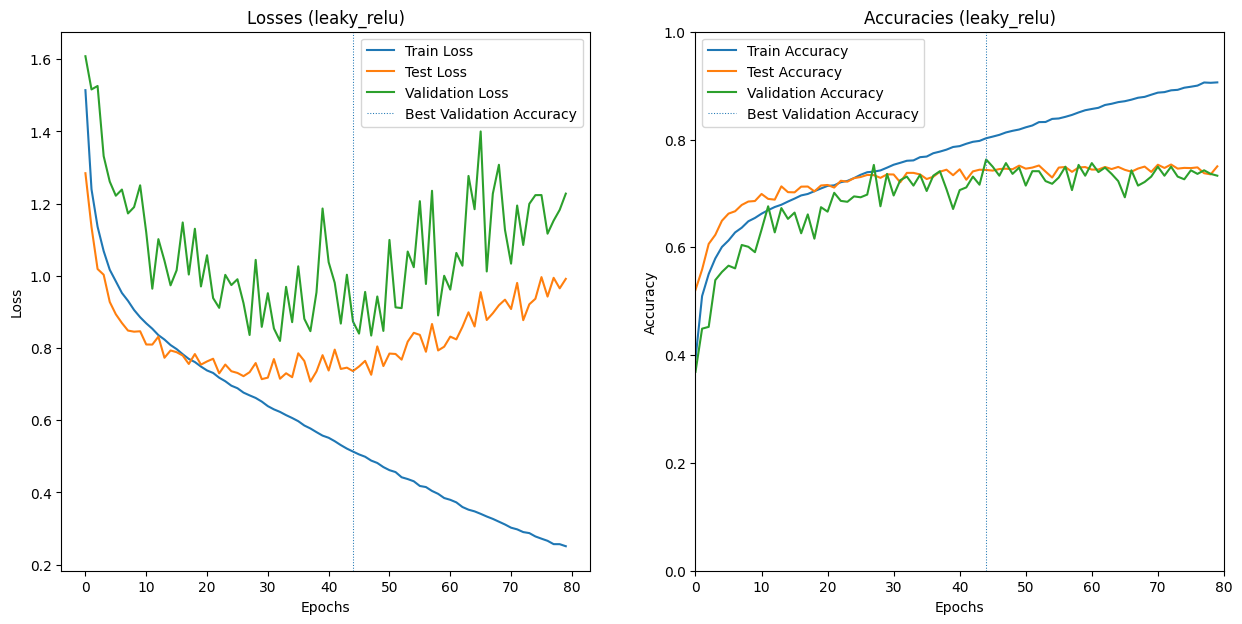

In [7]:
file_name = f"{output_path}/{experiment_name}/learning_curve.png"

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, label="Train Loss")
plt.plot(range(num_epochs), test_losses, label="Test Loss")
plt.plot(range(num_epochs), val_losses, label="Validation Loss")
plt.axvline(
    linewidth=0.75, x=best_acc_epoch, linestyle=":", label="Best Validation Accuracy"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Losses ({experiment_name})")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), train_accuracies, label="Train Accuracy")
plt.plot(range(num_epochs), test_accuracies, label="Test Accuracy")
plt.plot(range(num_epochs), val_accuracies, label="Validation Accuracy")
plt.axvline(
    linewidth=0.75, x=best_acc_epoch, linestyle=":", label="Best Validation Accuracy"
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"Accuracies ({experiment_name})")
plt.legend()

ax = plt.gca()
ax.set_xlim([0, num_epochs])
ax.set_ylim([0, 1])

plt.savefig(file_name, dpi=400, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [8]:
df = pd.DataFrame(
    {
        "Epoch": range(
            1, num_epochs + 1
        ),  # change this number after '(1, _)' to num_epochs+1
        "Train Loss": train_losses,
        "Test Loss": test_losses,
        "Validation Loss": val_losses,
        "Train Accuracy": train_accuracies,
        "Test Accuracy": test_accuracies,
        "Validation Accuracy": val_accuracies,
    }
)
df.to_csv(
    f"{output_path}/{experiment_name}/result.csv",
    index=False,
)

In [9]:
model.load_state_dict(
    torch.load(f"{output_path}/{experiment_name}/model.pth", map_location=device)
)
model.eval()


def classify_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(image)
        probabilities = F.softmax(outputs, dim=1)
    scores = probabilities.cpu().numpy().flatten()
    rounded_scores = [round(score, 2) for score in scores]
    return rounded_scores


results = []
for img_filename in listdir(dataset["validation"]["images"]):
    if img_filename.lower().endswith((".png", ".jpg", ".jpeg")):
        img_path = path.join(dataset["validation"]["images"], img_filename)
        scores = classify_image(img_path)
        results.append([img_path] + scores)

header = [
    "filepath",
    "happiness",
    "surprise",
    "sadness",
    "anger",
    "disgust",
    "fear",
]
with open(
    f"{output_path}/{experiment_name}/validation_classification_scores.csv",
    "w",
    newline="",
) as file:
    writer = csv.writer(file)
    writer.writerow(header)
    writer.writerows(results)

/var/folders/7v/r5yp07196sx_fx1lqtntzf4m0000gn/T/ipykernel_14516/2618999602.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"{output_path}/{experiment_name}/

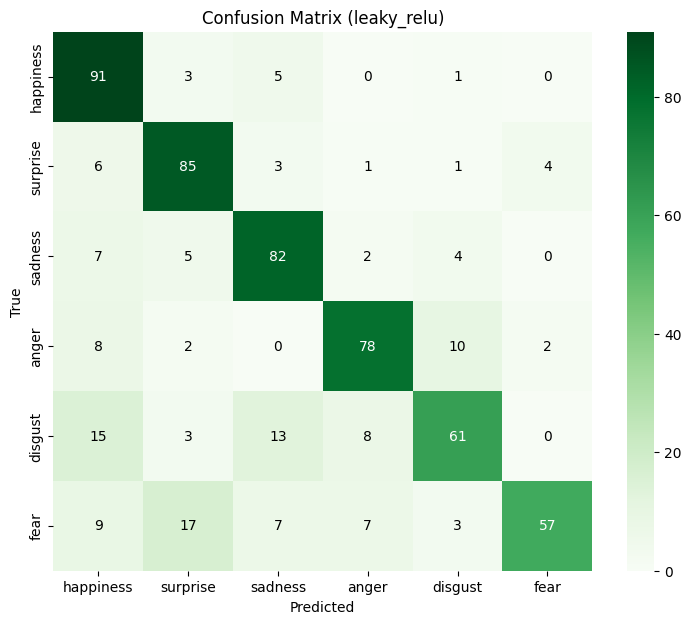

In [10]:
file_name = f"{output_path}/{experiment_name}/confusion_matrix.png"
scores_file = f"{output_path}/{experiment_name}/validation_classification_scores.csv"


df = pd.read_csv(scores_file)
class_names = ["happiness", "surprise", "sadness", "anger", "disgust", "fear"]
df["true"] = df["filepath"].apply(lambda x: x.split("_")[1].split(".")[0])
df["predicted"] = df[class_names].idxmax(axis=1)

confusion_matrix = pd.crosstab(
    df["true"], df["predicted"], rownames=["True"], colnames=["Predicted"]
)
confusion_matrix = confusion_matrix.reindex(
    index=class_names, columns=class_names, fill_value=0
)

plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    confusion_matrix, fmt="d", cmap="Greens", square=True, cbar=True, annot_kws=None
)  # cmap= PiYG, Blues, BuPu, Greens, Oranges, YlGnBu, coolwarm
for i, row in enumerate(confusion_matrix.values):
    for j, val in enumerate(row):
        text_color = "white" if i == j else "black"
        ax.text(j + 0.5, i + 0.5, val, color=text_color, ha="center", va="center")
plt.title(f"Confusion Matrix ({experiment_name})")
plt.savefig(file_name, dpi=400, bbox_inches="tight", pad_inches=0.1)